In [1]:
# Imports for t-SNE analysis
from data_preprocessing import split_data,standardize_dates, add_days_to_floraison, NIRS_INDEXES, NIRS_INDEXES_INT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import umap

/home/dodo/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load and preprocess data

data = pd.read_csv("./Data/CIRAD_Sorghum2023_SPIR_all_2 (4).csv", sep=";")
data = standardize_dates(data)
data = add_days_to_floraison(data)
data.head()

,Genotype,Sample,ID,Date_Floraison,Date_SPIR,Traitement,Rep,Position,350,351,...,2492,2493,2494,2495,2496,2497,2498,2499,2500,Dates_Delta
0,Btx623,FreshLeaf,117,2023-05-19,2023-06-01,C,1,FlagLeaf,0.075652,0.070583,...,0.085991,0.085268,0.084832,0.084246,0.083982,0.083914,0.083658,0.083273,0.083111,13
1,Btx623,FreshLeaf,117,2023-05-19,2023-06-01,C,2,FlagLeaf,0.083377,0.082926,...,0.101342,0.101169,0.100833,0.100403,0.100057,0.099492,0.099523,0.099310,0.099126,13
2,Macia,FreshLeaf,203,2023-05-23,2023-06-01,SS2,1,FlagLeaf,0.078272,0.075389,...,0.078159,0.078018,0.077781,0.077200,0.077168,0.077273,0.077200,0.077064,0.076751,9
3,Macia,FreshLeaf,203,2023-05-23,2023-06-01,SS2,2,FlagLeaf,0.075764,0.074639,...,0.078284,0.078045,0.077868,0.077812,0.077722,0.077669,0.077620,0.077650,0.077399,9
4,Macia,FreshLeaf,215,2023-05-24,2023-06-01,C,1,FlagLeaf,0.061362,0.060504,...,0.068550,0.068382,0.068200,0.068012,0.067757,0.067621,0.067635,0.067188,0.067004,8


In [3]:
# Prepare spectral matrix and scale

X = data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)

# run t-SNE in 2 dimensions

tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE shape", X_tsne.shape)


t-SNE shape (2174, 2)


In [4]:
def plot_tsne(db,label_name, title=None, palette='viridis'):
    df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    df[label_name] = db[label_name].values
    plt.figure(figsize=(12,6))
    sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue=label_name,
                    palette=palette, s=50, alpha=0.8)
    plt.title(title or f"t-SNE colored by {label_name}")
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_UMAP_default(db, X_umap, label_name, tit):
    """Plot UMAP avec couleurs cohérentes entre scatter et légende"""
    fig, axe = plt.subplots(figsize=(12, 6))
    
    # Source de vérité unique : l'ordre des catégories
    categories = db[label_name].astype('category')
    labels_unique = categories.cat.categories  # ordre stable et garanti
    n = len(labels_unique)
    
    # Mapper chaque label à un code via ce même ordre
    codes = categories.cat.codes  # cohérent avec cat.categories
    
    scatter = axe.scatter(
        X_umap[:, 0], X_umap[:, 1],
        c=codes, cmap='viridis', vmin=0, vmax=n - 1,
        s=50, alpha=0.7
    )
    
    axe.set_title(tit)
    axe.set_xlabel('UMAP 1')
    axe.set_ylabel('UMAP 2')
    axe.grid(alpha=0.3)
    
    # Légende construite avec le MÊME ordre et les MÊMES couleurs normalisées
    handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=plt.cm.viridis(i / (n - 1) if n > 1 else 0),
                   markersize=10, label=lbl)
        for i, lbl in enumerate(labels_unique)
    ]
    axe.legend(handles=handles, loc='center right', title=label_name)
    
    plt.tight_layout()
    plt.show()



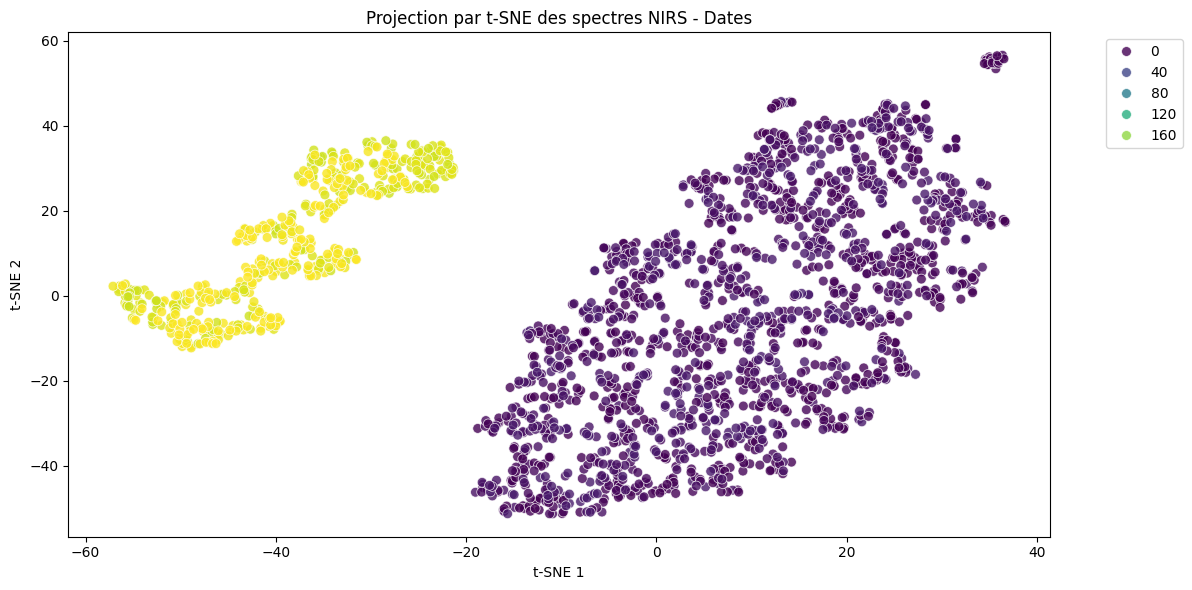

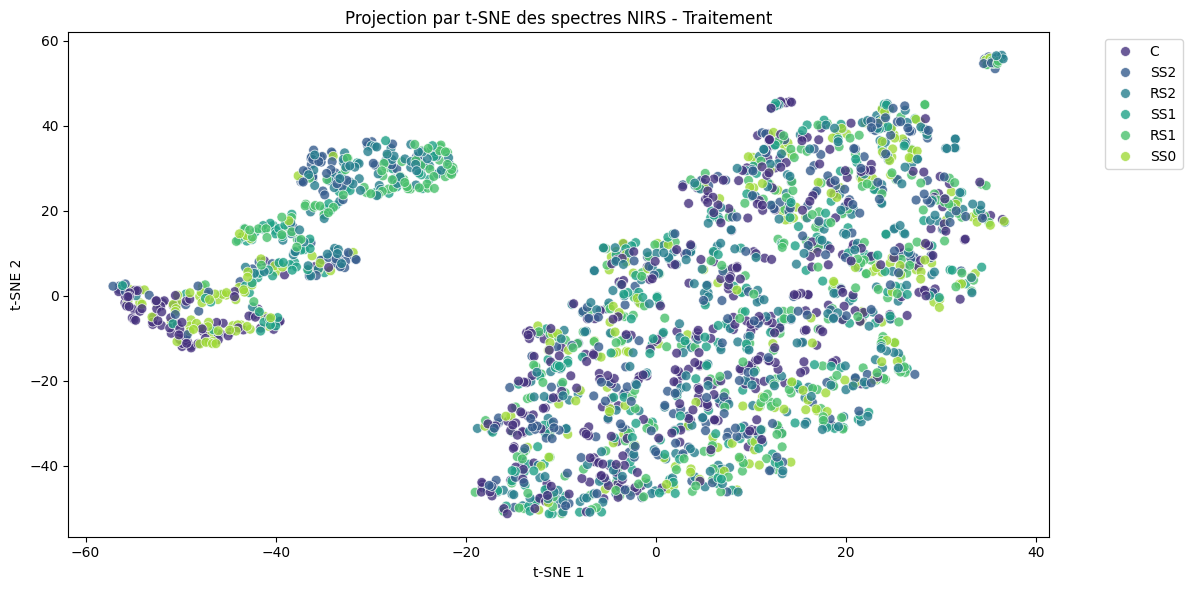

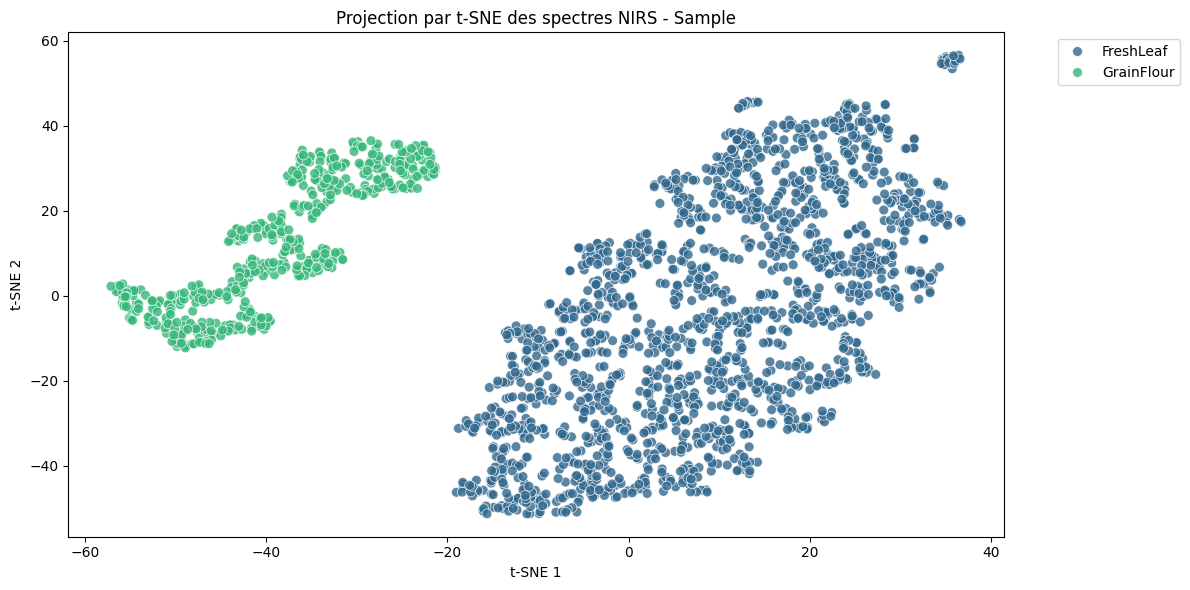

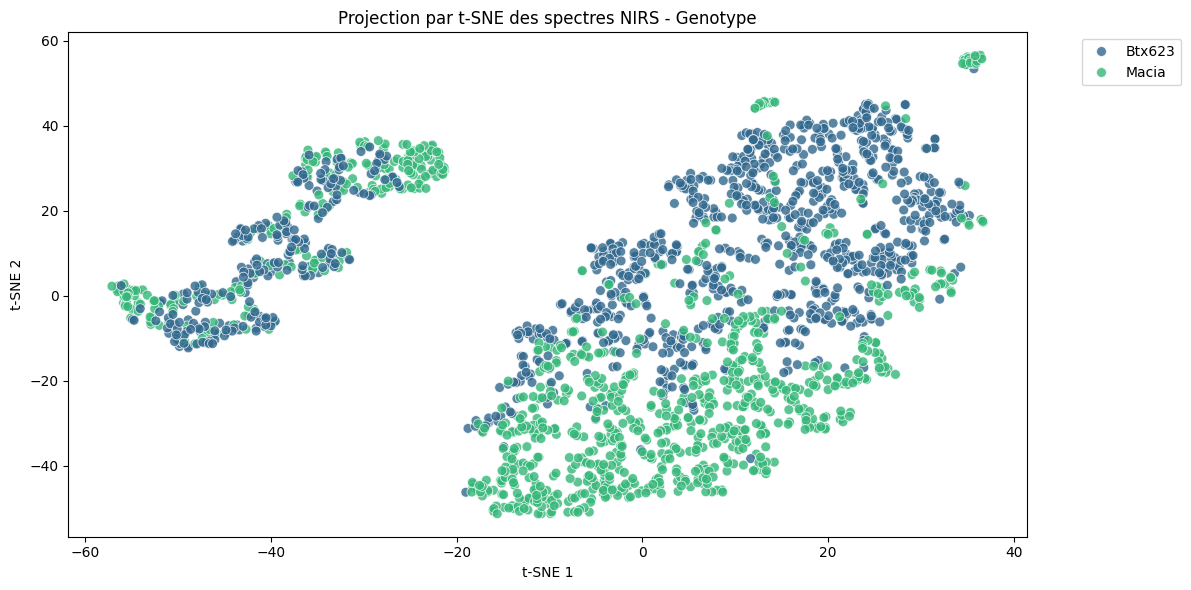

In [5]:
#premiers plot comme ACP
title_base = "Projection par t-SNE des spectres NIRS"
plot_tsne(data,'Dates_Delta', title=title_base + ' - Dates')
plot_tsne(data,'Traitement', title=title_base + ' - Traitement')
plot_tsne(data,'Sample', title=title_base + ' - Sample')
plot_tsne(data,'Genotype', title=title_base + ' - Genotype')

On en est au point précédent de l'ACP ou toutes les donées sont mise y ccompris les différents génotype, le sample ce qui est pas satisfaisant
Découpons tout cela 

In [6]:
groups = split_data(data)

btx_leaf_data = groups[("Btx623","FreshLeaf")]

btx_grain_data = groups[("Btx623","GrainFlour")]

macia_leaf_data = groups[("Macia","FreshLeaf")]

macia_grain_data = groups[("Macia","GrainFlour")]



In [7]:

# Prepare spectral matrix and scale
X = macia_leaf_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


# Calculer une perplexity adaptée
n_samples = len(macia_leaf_data)
recommended_perplexity = min(30, max(5, n_samples // 3))
print(f"Perplexity recommandée pour {n_samples} échantillons : {recommended_perplexity}")

# run t-SNE avec paramètres adaptés
tsne = TSNE(n_components=2, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

print(f"\nt-SNE shape : {X_tsne.shape}")

# UMAP avec min_dist élevé pour mieux espacer les points
reducer = umap.UMAP(random_state=42, min_dist=1, spread=2, n_neighbors=15)
X_umap = reducer.fit_transform(X_scaled)

Perplexity recommandée pour 806 échantillons : 30
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 806 samples in 0.032s...
[t-SNE] Computed neighbors for 806 samples in 0.074s...
[t-SNE] Computed conditional probabilities for sample 806 / 806
[t-SNE] Mean sigma: 4.215587
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.670689
[t-SNE] KL divergence after 2300 iterations: 0.755210

t-SNE shape : (806, 2)


/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


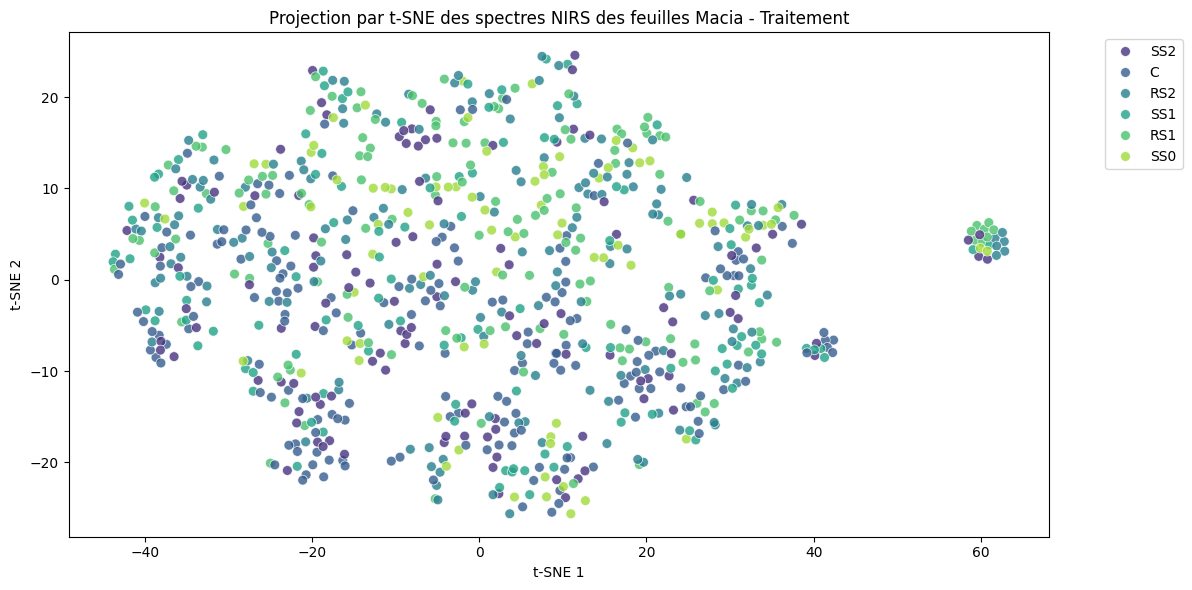

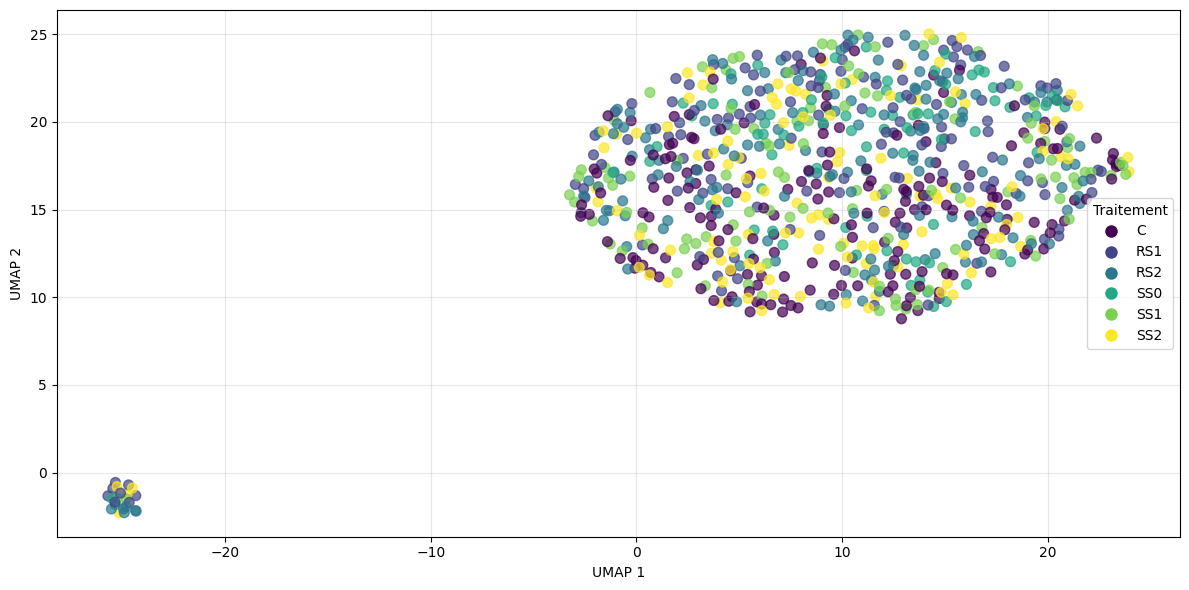

In [8]:


title_base = "Projection par t-SNE des spectres NIRS des feuilles Macia"
plot_tsne(macia_leaf_data,'Traitement', title=title_base + ' - Traitement')
plot_UMAP_default(macia_leaf_data,X_umap,'Traitement', '')



In [9]:

# Prepare spectral matrix and scale
X = btx_leaf_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


# Calculer une perplexity adaptée
n_samples = len(btx_leaf_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

# run t-SNE avec paramètres adaptés
tsne = TSNE(n_components=2, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

print(f"\nt-SNE shape : {X_tsne.shape}")

# UMAP avec min_dist élevé pour mieux espacer les points
reducer = umap.UMAP(random_state=42, min_dist=1, spread=2, n_neighbors=15)
X_umap = reducer.fit_transform(X_scaled)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 892 samples in 0.019s...
[t-SNE] Computed neighbors for 892 samples in 0.064s...
[t-SNE] Computed conditional probabilities for sample 892 / 892
[t-SNE] Mean sigma: 8.577908
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.794029
[t-SNE] KL divergence after 3000 iterations: 0.820088

t-SNE shape : (892, 2)


/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


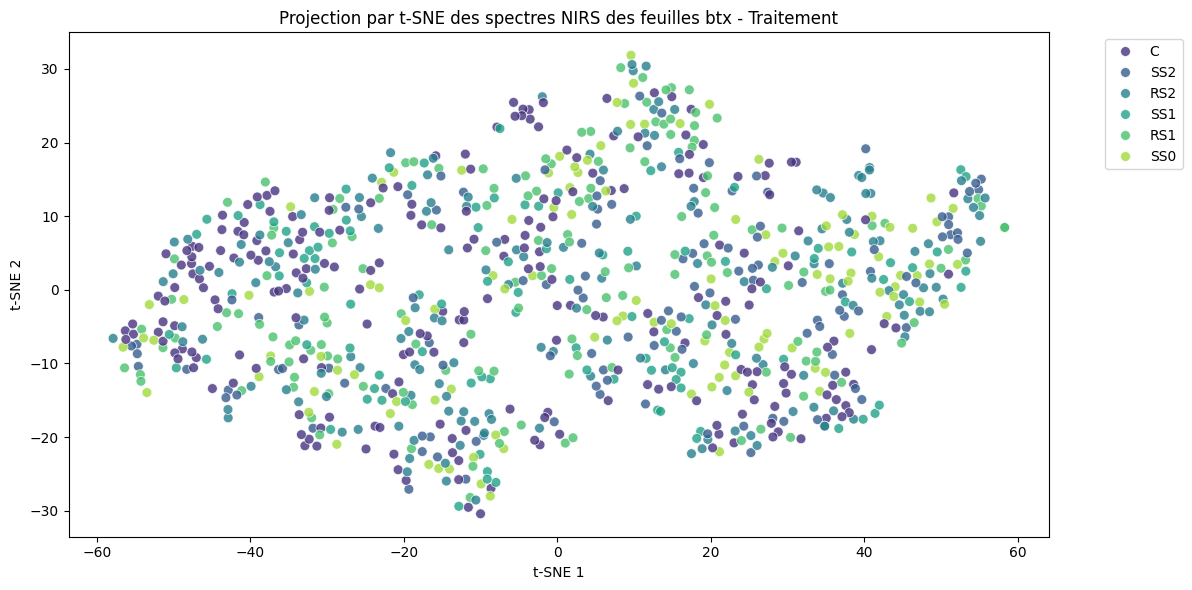

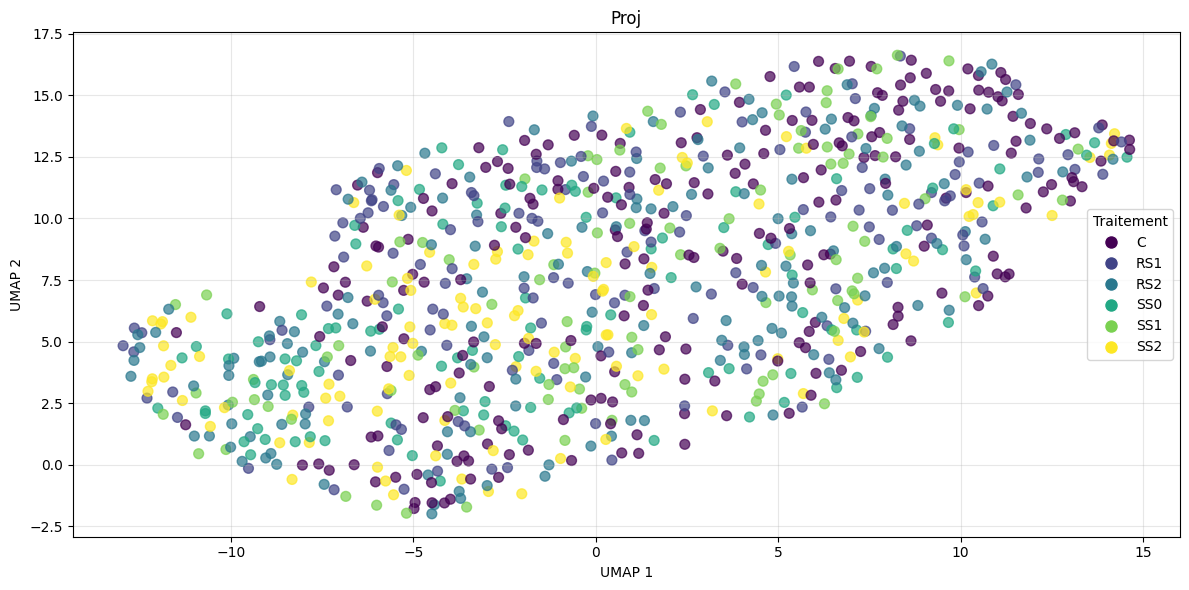

In [10]:
title_base = "Projection par t-SNE des spectres NIRS des feuilles btx"
plot_tsne(btx_leaf_data,'Traitement', title=title_base + ' - Traitement')

# Plot UMAP
plot_UMAP_default(btx_leaf_data,X_umap,'Traitement',"Proj")


In [11]:

# Prepare spectral matrix and scale
X = btx_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


# Calculer une perplexity adaptée
n_samples = len(btx_grain_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

# run t-SNE avec paramètres adaptés
tsne = TSNE(n_components=2, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

print(f"\nt-SNE shape : {X_tsne.shape}")


# UMAP avec min_dist élevé pour mieux espacer les points
reducer = umap.UMAP(random_state=42, min_dist=0.5, spread=1.5, n_neighbors=15)
X_umap = reducer.fit_transform(X_scaled)



[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 236 samples in 0.006s...
[t-SNE] Computed neighbors for 236 samples in 0.022s...
[t-SNE] Computed conditional probabilities for sample 236 / 236
[t-SNE] Mean sigma: 15.291541
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.203106
[t-SNE] KL divergence after 1100 iterations: 0.360015

t-SNE shape : (236, 2)


/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


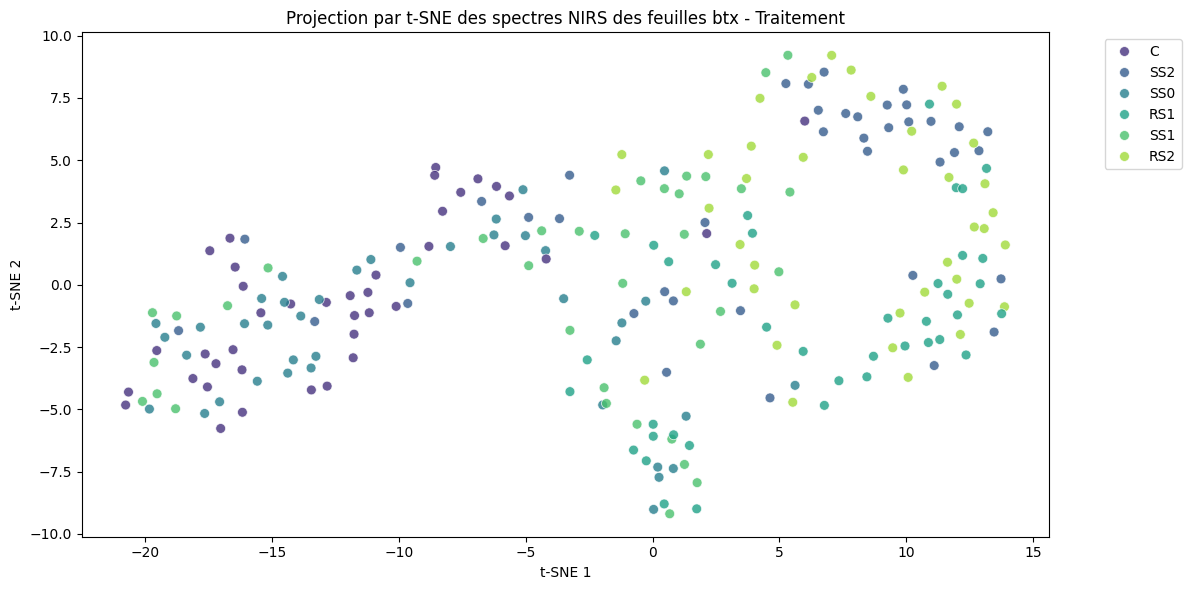

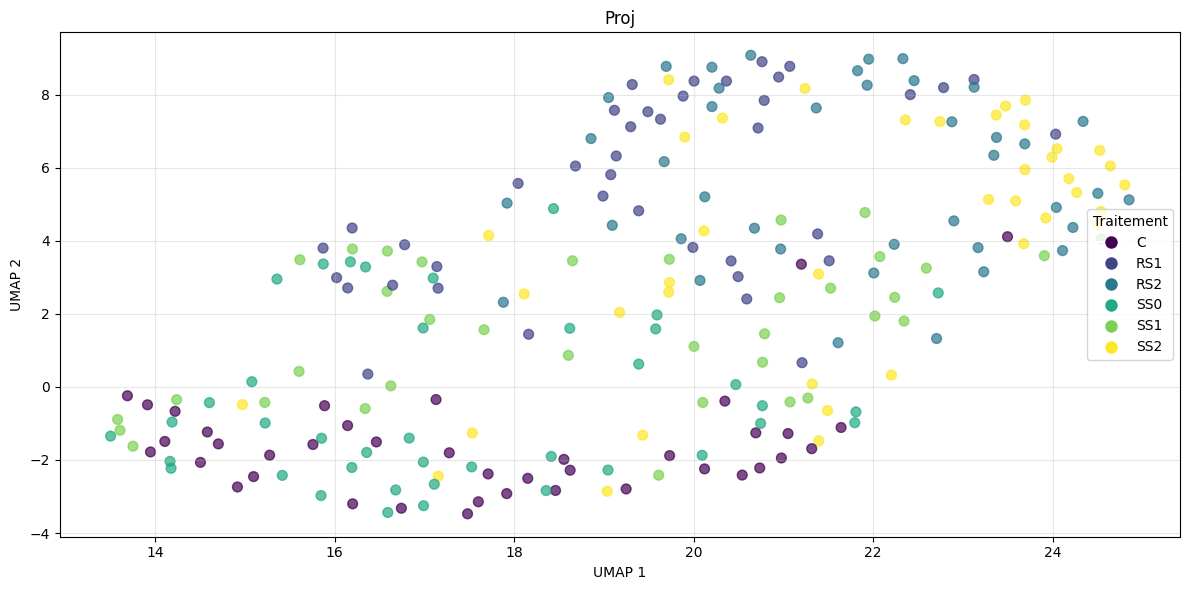

In [12]:
title_base = "Projection par t-SNE des spectres NIRS des feuilles btx"
plot_tsne(btx_grain_data,'Traitement', title=title_base + ' - Traitement')

# Plot UMAP
plot_UMAP_default(btx_grain_data,X_umap,'Traitement',"Proj")

In [13]:

# Prepare spectral matrix and scale
X = macia_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


# Calculer une perplexity adaptée
n_samples = len(macia_grain_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

# run t-SNE avec paramètres adaptés
tsne = TSNE(n_components=2, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

print(f"\nt-SNE shape : {X_tsne.shape}")


# UMAP avec min_dist élevé pour mieux espacer les points
reducer = umap.UMAP(random_state=42, min_dist=1, spread=2, n_neighbors=15)
X_umap = reducer.fit_transform(X_scaled)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 240 samples in 0.009s...
[t-SNE] Computed neighbors for 240 samples in 0.014s...
[t-SNE] Computed conditional probabilities for sample 240 / 240
[t-SNE] Mean sigma: 14.148323
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.793976
[t-SNE] KL divergence after 1200 iterations: 0.354801

t-SNE shape : (240, 2)


/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


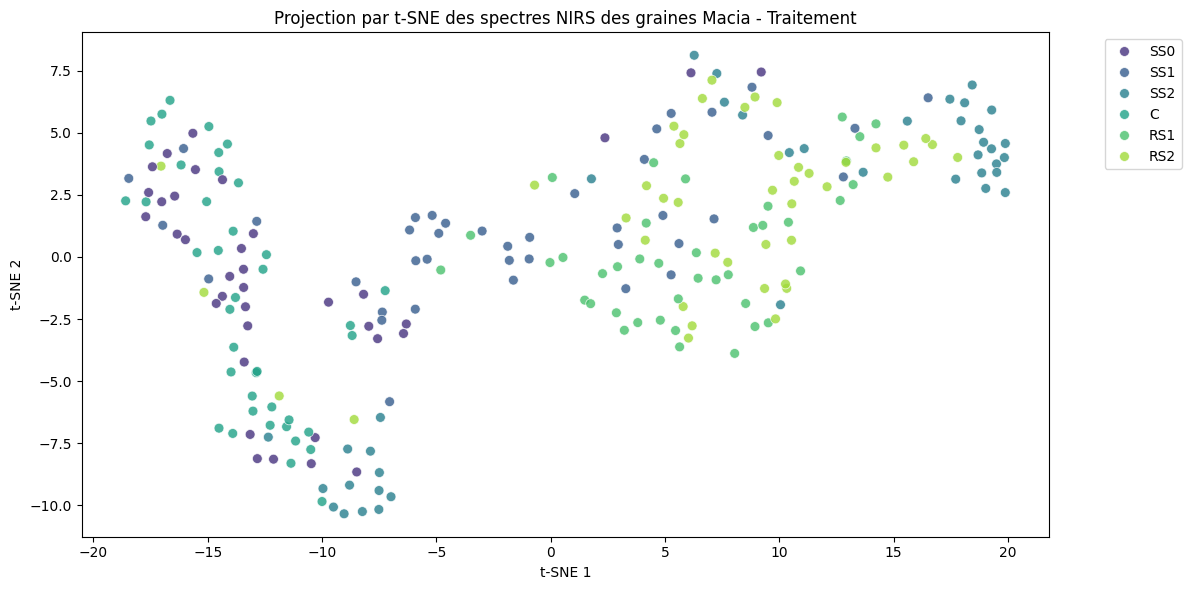

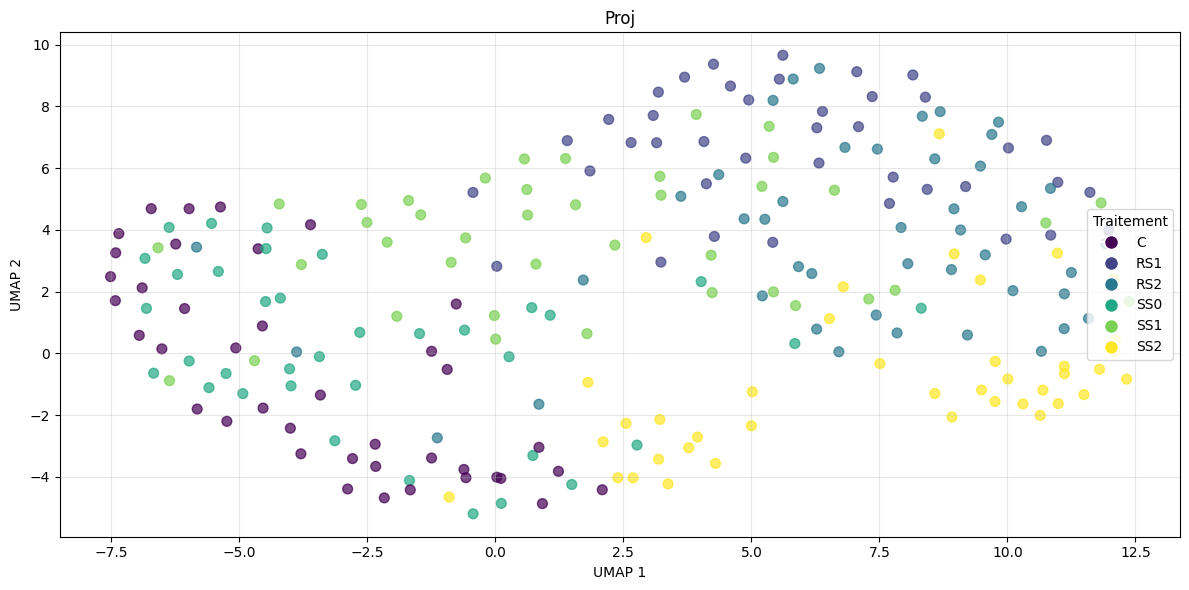

In [14]:
title_base = "Projection par t-SNE des spectres NIRS des graines Macia"
plot_tsne(macia_grain_data,'Traitement', title=title_base + ' - Traitement')

# Plot UMAP
plot_UMAP_default(macia_grain_data,X_umap,'Traitement',"Proj")

In [15]:
# ==== Quantifier la séparabilité des groupes =====
from scipy.spatial.distance import pdist, squareform

X = macia_leaf_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)
traitements = macia_leaf_data['Traitement'].values

# Calculer distances euclidiennes
distances = squareform(pdist(X_scaled, metric='euclidean'))

# Pour chaque traitement, calculer distances intra et inter-groupes
traitements_uniques = np.unique(traitements)
print("Analyse des distances (données standardisées) :\n")

distances_intra = []
distances_inter = []

for trait in traitements_uniques:
    mask = traitements == trait
    n_samples_trait = mask.sum()
    
    if n_samples_trait < 2:
        continue
    
    # Distances intra-groupe (entre échantillons du même traitement)
    indices = np.where(mask)[0]
    dist_intra = distances[np.ix_(indices, indices)]
    dist_intra = dist_intra[np.triu_indices_from(dist_intra, k=1)]  # Matrice triangulaire sup
    
    # Distances inter-groupes (entre ce traitement et les autres)
    indices_autres = np.where(~mask)[0]
    if len(indices_autres) > 0:
        dist_inter = distances[np.ix_(indices, indices_autres)]
        print(f"    - Ratio inter/intra : {dist_inter.mean() / dist_intra.mean():.2f}")
        
        distances_intra.extend(dist_intra)
        distances_inter.extend(dist_inter.flatten())

print("   < 1.2 : Groupes très chevauchés → difficile à séparer")
print("   1.2-2.0 : Séparation modérée → nécessite algorithme non-linéaire")
print("   > 2.0 : Groupes bien séparés → devrait clustériser facilement")


Analyse des distances (données standardisées) :

    - Ratio inter/intra : 1.38
    - Ratio inter/intra : 0.88
    - Ratio inter/intra : 0.91
    - Ratio inter/intra : 1.14
    - Ratio inter/intra : 1.02
    - Ratio inter/intra : 0.99
   < 1.2 : Groupes très chevauchés → difficile à séparer
   1.2-2.0 : Séparation modérée → nécessite algorithme non-linéaire
   > 2.0 : Groupes bien séparés → devrait clustériser facilement


Moralité : On a des groupes tres chevaucher qui est difficile à distinguer. Cependant on constate sur les graines qu'il semble y avoir des superpositions de groupes sur les graines la suite de nos projection vont se porter sur cela.

On poursuit alors en essayant de comparer les projections entre t-SNE et UMAP

/home/dodo/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 240 samples in 0.002s...
[t-SNE] Computed neighbors for 240 samples in 0.013s...
[t-SNE] Computed conditional probabilities for sample 240 / 240
[t-SNE] Mean sigma: 14.148323
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.793980
[t-SNE] KL divergence after 1200 iterations: 0.354801


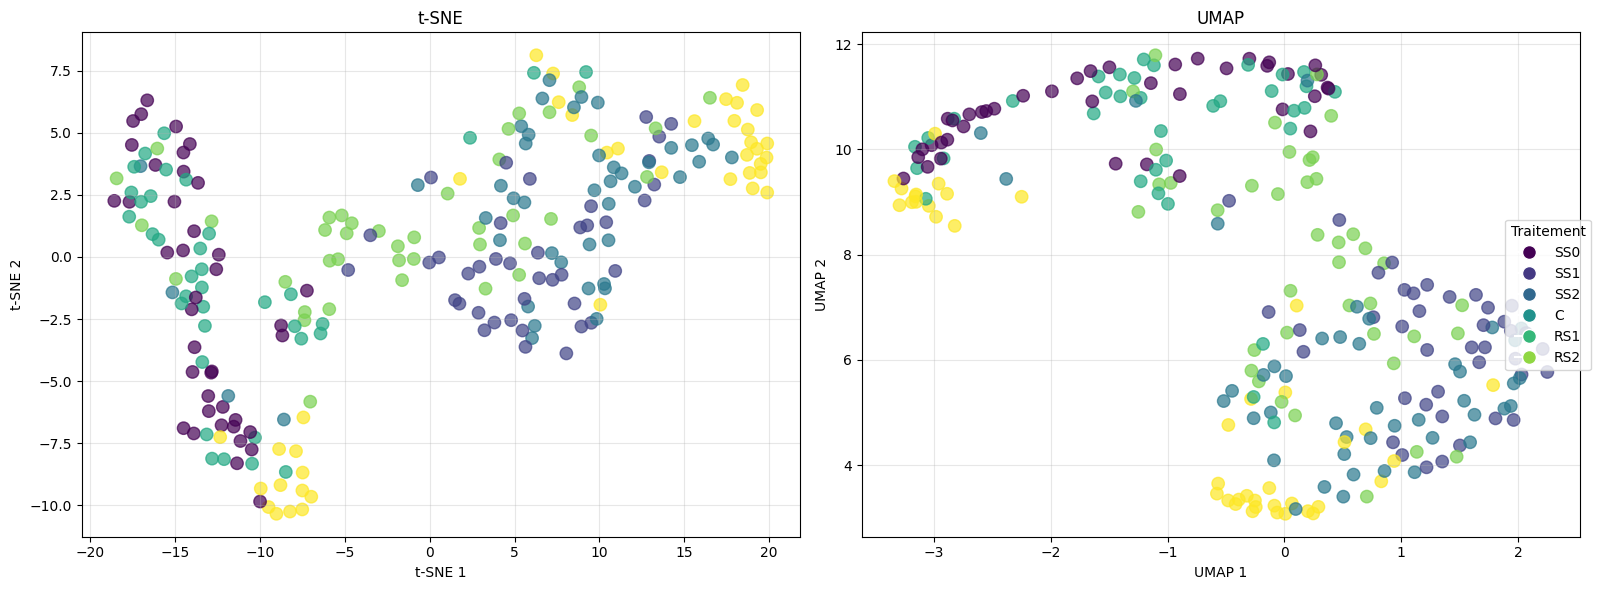

In [16]:

X = macia_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)
    
# UMAP avec paramètres par défaut
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# t-SNE avec paramètres par dégaut
tsne = TSNE(n_components=2, 
            perplexity=30, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)
    
# Comparaison t-SNE vs UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#récupérations des différents valeur de traitement
colors = macia_grain_data['Traitement'].astype('category').cat.codes
    
# t-SNE
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, cmap='viridis', s=80, alpha=0.7)
axes[0].set_title('t-SNE')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(alpha=0.3)
    
# UMAP
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, cmap='viridis', s=80, alpha=0.7)
axes[1].set_title('UMAP')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].grid(alpha=0.3)
    
labels_unique = macia_grain_data['Traitement'].unique()
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor=plt.cm.viridis(i/len(labels_unique)), 
                          markersize=10, label=lbl) 
              for i, lbl in enumerate(labels_unique)]
fig.legend(handles=handles, loc='center right', title='Traitement')
    
plt.tight_layout()
plt.show()
    


Le résultat semble souvent présenter des clusters superposé mais on ne peut pas vraiment en dire plus, les résultats sont vraiment tres similaire mais on peut se poser la question d'augementer la dimension de projection

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 236 samples in 0.003s...
[t-SNE] Computed neighbors for 236 samples in 0.017s...
[t-SNE] Computed conditional probabilities for sample 236 / 236
[t-SNE] Mean sigma: 15.291541
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.267281
[t-SNE] KL divergence after 650 iterations: 0.243662


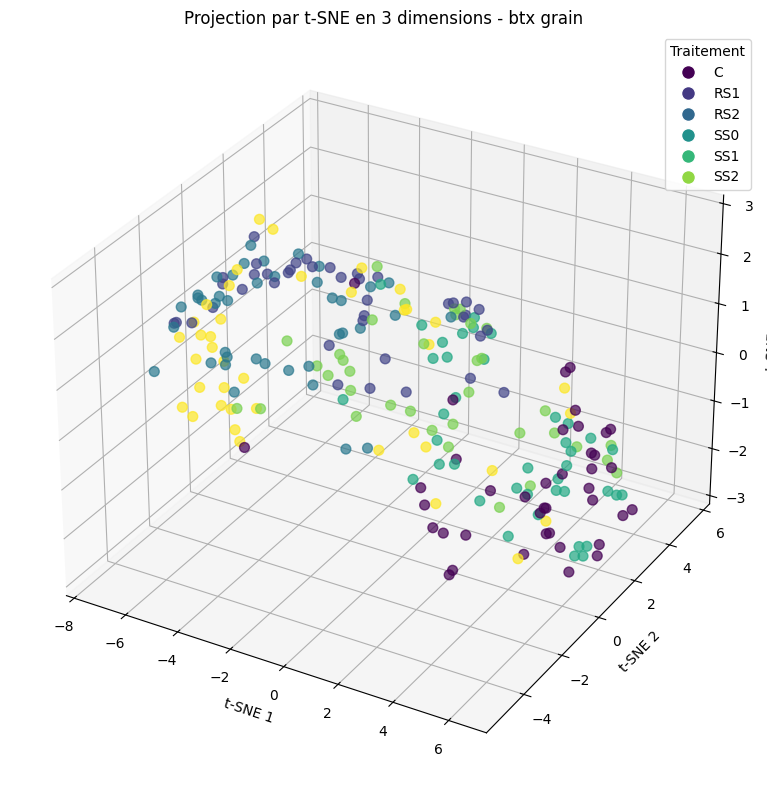

In [17]:

# Prepare spectral matrix and scale
X = btx_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)

# Calculer une perplexity adaptée
n_samples = len(btx_grain_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

# run t-SNE en 3 dimensions
tsne = TSNE(n_components=3, 
            perplexity=recommended_perplexity, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

# Plot 3D manuel
categories = btx_grain_data['Traitement'].astype('category')
colors = categories.cat.codes
labels_unique = categories.cat.categories

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2],
           c=colors, cmap='viridis', s=50, alpha=0.7)
ax.set_title("Projection par t-SNE en 3 dimensions - btx grain")
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=plt.cm.viridis(i / len(labels_unique)),
                      markersize=10, label=lbl)
           for i, lbl in enumerate(labels_unique)]
ax.legend(handles=handles, title='Traitement')
plt.tight_layout()
plt.show()


In [18]:
import plotly.express as px

n = len(labels_unique)
viridis_colors = px.colors.sample_colorscale(
    'viridis', [i / (n - 1) for i in range(n)]
)

color_map = {lbl: viridis_colors[i] for i, lbl in enumerate(labels_unique)}
color_labels = [labels_unique[c] for c in colors]
fig = px.scatter_3d(
x=X_tsne[:,0], y=X_tsne[:,1], z=X_tsne[:,2],
color=color_labels,
color_discrete_map=color_map,
opacity=0.8,
labels={'x': 't-SNE 1', 'y': 't-SNE 2', 'z': 't-SNE 3', 'color': 'Traitement'},
title="Projection t-SNE 3D — Traitement"
)
fig.show()

In [19]:
##passage intégrale sous ploty pour pouvoir faire de l'affichage 2 à 2 et interactif

def t_SNE_2D_display(X_tsne,data,title):
    categories = data['Traitement'].astype('category')
    colors = categories.cat.codes
    labels_unique = categories.cat.categories
    n = len(labels_unique)
    viridis_colors = px.colors.sample_colorscale(
        'viridis', [i / (n - 1) for i in range(n)]
    )

    color_map = {lbl: viridis_colors[i] for i, lbl in enumerate(labels_unique)}
    color_labels = [labels_unique[c] for c in colors]

    fig = px.scatter(
    x=X_tsne[:,0], y=X_tsne[:,1],
    color=color_labels,
    color_discrete_map=color_map,
    opacity=0.8,
    labels={'x': 't-SNE 1', 'y': 't-SNE 2', 'z': 't-SNE 3', 'color': 'Traitement'},
    title=title
    )
    #fixation béton
    fig.update_layout(
    xaxis=dict(range=[X_tsne[:, 0].min() - 1, X_tsne[:, 0].max() + 1]),
    yaxis=dict(range=[X_tsne[:, 1].min() - 1, X_tsne[:, 1].max() + 1])
    )
    fig.show()

In [20]:
X = macia_grain_data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)

# t-SNE avec paramètres par dégaut
tsne = TSNE(n_components=2, 
            perplexity=30, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

t_SNE_2D_display(X_tsne,macia_grain_data,"Projection T-sne graine de Macia en 2D interactif")

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 240 samples in 0.003s...
[t-SNE] Computed neighbors for 240 samples in 0.014s...
[t-SNE] Computed conditional probabilities for sample 240 / 240
[t-SNE] Mean sigma: 14.148323
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.793976
[t-SNE] KL divergence after 1200 iterations: 0.354801


On constate ici certain cluserts de points qui se forme et sur lequel on va pouvoir, faire certains traitement sur des ensembles disjoint.

Constate que le plus notable est C et RS1 qui sont totalement disjoint on peut alors avoir deux régions propres et différencier des traitements inconnue si ils sont parmi ces deux classe. On peut aussi interpréter cela comme étant le fait que la plante a subit un changement signification avec la chaleur au point d'être différenciable totalement des données de Controles.

Le Constat est Similaire pour C et RS2 on va constater que RS2 est très proche de RS1 meme si certaines données se confonde avec les données de controles

Les 2 classes SS1,SS2 semblent avoir des comportements similaires assez disparate sur la projection et sont difficilement interprétable. Cependant SS0 lui semble avoir un comportement assez proche du traitement de Controle. On peut éventuellement interpréter que l'impact de la chaleur ne va pas avoir de conséquences fondatmentale sur la plante tandis que appliquer des pics de chaleurs plus tard dans son cycle de vie va laisser une marque (marque éventuellemnt d'adaptation a son environnement) durable.


Notre objectif maintenant va être d'incorporer nos données physico chimimique cependant leurs données sont relativement de nos données utiliser précédament, a commencer par leurs experience réaliser de ce fait on va venir les modifiers pour que elle soit raccord au travail précédent et éventuellement les incorporés a nos données 

In [21]:
data_chimique = pd.read_excel("./Data/NIRS seeds_quality_plant Leo_2023-2024_LORIA_v3_26032025.xlsx",sheet_name="NIRS seeds Leo (2023-2024)", engine="openpyxl", header=0)

data_chimique.drop(columns=['file name'])

,cohort,plante number,modality,FA,SFA,UFA,w6w3,MUFA,PUFA,%N,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,Seeds_Pods_Flowers,101,EP+HP,34.959306,2.852463,32.106842,1.730085,19.669549,12.437293,3.55,...,0.135267,0.135519,0.136074,0.136199,0.136177,0.136157,0.135908,0.135719,0.135715,0.135768
1,Seeds_Pods_Flowers,103,EP+HP,27.088366,2.505987,24.582379,2.089002,14.765187,9.817192,3.73,...,0.278833,0.278868,0.279081,0.279231,0.279447,0.279574,0.279650,0.279686,0.279678,0.279674
2,Seeds_Pods_Flowers,104,EP+HP,30.812729,2.574839,28.237891,1.796420,16.109186,12.128705,4.02,...,0.308820,0.308756,0.308777,0.308801,0.308697,0.308866,0.309319,0.309598,0.309741,0.309804
3,Seeds_Pods_Flowers,106,IP+HP,36.782394,2.951565,33.830829,1.759056,21.122271,12.708557,3.68,...,0.360397,0.360263,0.360079,0.359980,0.359795,0.359830,0.360040,0.360070,0.360163,0.360165
4,Seeds_Pods_Flowers,107,IP+HP,37.892100,3.077230,34.814870,1.935777,22.719796,12.095074,3.12,...,0.085382,0.085291,0.085310,0.085343,0.085265,0.085273,0.085504,0.085550,0.085728,0.085749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Seeds_Pods<5cm,126,IP,30.456570,2.590096,27.866474,1.946520,17.143769,10.722706,3.71,...,0.055736,0.055732,0.055681,0.055713,0.055761,0.055732,0.055731,0.055721,0.055774,0.056086
68,Seeds_Pods<5cm,127,IP,34.803282,2.719817,32.083465,1.924331,20.254855,11.828610,3.33,...,0.059501,0.059585,0.059828,0.059974,0.059920,0.059996,0.060200,0.060212,0.060327,0.060295
69,Seeds_Pods<5cm,129,LP,35.209217,2.796524,32.412693,1.899094,20.720728,11.691965,3.09,...,0.061210,0.061332,0.061587,0.061718,0.061741,0.061767,0.061778,0.061749,0.061783,0.061804
70,Seeds_Pods<5cm,131,LP,29.900596,2.502307,27.398289,1.651941,16.504157,10.894132,3.30,...,0.050379,0.050332,0.050193,0.050185,0.050236,0.050258,0.050446,0.050409,0.050518,0.050674


```
modality_map : 
    'EP':    'SS1',  # Early priming         → Early single stress
    'IP':    'SS2',  # Intermediate priming  → Late single stress
    'LP':    'SS2',  # Late priming          → Late single stress (même timing que IP ?)
    'EP+HS': 'RS1',  # Early priming + HS    → Early recurrent stress
    'IP+HS': 'RS2',  # Intermediate priming + HS → Late recurrent stress
    'LP+HS': 'RS2',  # Late priming + HS     → Late recurrent stress (même que IP+HS ?)
    'HS':    'SS0',  # Heat stress seul      → Flo stress
    'C':     'C',    # Control               → Control
```


In [22]:

data_chimique['modality'] = data_chimique['modality'].replace('HS', 'SS0')
data_chimique['modality'] = data_chimique['modality'].replace('EP', 'SS1')
data_chimique['modality'] = data_chimique['modality'].replace('IP', 'SS2') #?
data_chimique['modality'] = data_chimique['modality'].replace('LP', 'SS2')
data_chimique['modality'] = data_chimique['modality'].replace('EP+HP', 'RS1')
data_chimique['modality'] = data_chimique['modality'].replace('IP+HP', 'RS2') # ?
data_chimique['modality'] = data_chimique['modality'].replace('LP+HP', 'RS2')
# data_chimique = data_chimique.drop_duplicates(subset='plante number') #divise le nombres de plantes par 3 comme chaque plante est teser 3 fois 
print(data_chimique["modality"].value_counts())
data_chimique["Origine"] = "NIRS"
btx_grain_data["Origine"] = "Circad"

data_chimique.columns = [str(int(c)) if str(c).replace('.','').isdigit() else c 
                         for c in data_chimique.columns]
data_chimique = data_chimique.rename(columns={'modality': 'Traitement'})


nirs_set_1 = set(btx_grain_data.columns) & set(NIRS_INDEXES)
nirs_set_2 = set(data_chimique.columns) & set(NIRS_INDEXES)
NIRS_COMMON = list(nirs_set_1 & nirs_set_2)
print(f"{len(NIRS_COMMON)} colonnes NIRS en commun")


modality
RS2    18
SS2    18
RS1     9
C       9
HP      9
SS1     9
Name: count, dtype: int64
2151 colonnes NIRS en commun


/tmp/ipykernel_4836/2375156115.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [23]:

cols_needed = NIRS_COMMON + ['Traitement', 'Origine']
data_merged = pd.concat([
    btx_grain_data[cols_needed],
    data_chimique[cols_needed]
], axis=0).reset_index(drop=True)

X = data_merged[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)


tsne = TSNE(n_components=2, perplexity=recommended_perplexity,
            max_iter=3000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

#data_frame prep pour le plot
df_plot = pd.DataFrame({
    'tSNE1':    X_tsne[:, 0],
    'tSNE2':    X_tsne[:, 1],
    'Traitement': data_merged['Traitement'],
    'Origine':    data_merged['Origine'],
})

# on adapte le plot précédent pour distinguer l'origine en plus
n = len(df_plot['Traitement'].unique())
viridis_colors = px.colors.sample_colorscale(
    'viridis', [i / (n - 1) for i in range(n)]
)
color_map = {lbl: viridis_colors[i] 
             for i, lbl in enumerate(sorted(df_plot['Traitement'].unique()))}

fig = px.scatter(
    df_plot,
    x='tSNE1', y='tSNE2',
    color='Traitement',      
    symbol='Origine',       
    symbol_map={
        'NIRS':  'circle',
        'CIRAD': 'star'  
    },
    color_discrete_map=color_map,
    opacity=0.8,
    labels={'tSNE1': 't-SNE 1', 'tSNE2': 't-SNE 2'},
    title="t-SNE — NIRS vs CIRAD"
)

fig.update_layout(
    xaxis=dict(range=[X_tsne[:, 0].min() - 1, X_tsne[:, 0].max() + 1]),
    yaxis=dict(range=[X_tsne[:, 1].min() - 1, X_tsne[:, 1].max() + 1]),
    legend=dict(groupclick="toggleitem")
)

fig.show()


On constate le résultat que l'on ne voulait absolument pas soit que les données sont intégralement séparer, on en tire la conclusion que les données CIRAD et les données NIRS ne sont absolument pas mélangeable entre elles car sont séparer probablement du aux variations des protocoles ici on va essayer de voir ce quil se passe dans le cas ou on prends les autre données NIRS plus abondante pour voir si on peut les mélanger.

In [24]:
#init
data_chimique = pd.read_excel("./Data/NIRS seeds_quality_plant Leo_2023-2024_LORIA_v3_26032025.xlsx",sheet_name="NIRS seeds Leo (2023-2024)", engine="openpyxl", header=0)

data_chimique = data_chimique.drop(columns=['file name'])


data_nirs  =  pd.read_excel("./Data/Fichier NIRS-Exp 2023-2024-mesures dynamiques.xlsx",sheet_name="raw data (3)", engine="openpyxl", header=1)

data_nirs = data_nirs.drop(columns=['nom du fichier'])

data_nirs.head()

,libellé échantillon,Unnamed: 2,codes dates récoltes,Age plante en °Cj (depuis début traitement T°C),Age plante °Cj (approx pour comparaison),organe,traitement,350,351,352,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,240424F CTRL 134.asd,2024-04-24,S0 (0°Cj),0,debut séquence,F,control,0.363791,0.205500,0.296885,...,0.097163,0.097133,0.096866,0.097584,0.099971,0.100867,0.101093,0.102318,0.102553,0.102371
1,240424F CTRL 135.asd,2024-04-24,S0 (0°Cj),0,debut séquence,F,control,0.262947,0.361647,0.351043,...,0.060797,0.060796,0.061413,0.061622,0.060834,0.060777,0.061298,0.061022,0.061002,0.060627
2,240424F CTRL 136.asd,2024-04-24,S0 (0°Cj),0,debut séquence,F,control,0.282860,0.331093,0.355294,...,0.056187,0.056158,0.055840,0.056117,0.057674,0.057835,0.057409,0.056684,0.056050,0.055294
3,240424F CTRL 137.asd,2024-04-24,S0 (0°Cj),0,debut séquence,F,control,0.326898,0.347866,0.344546,...,0.070763,0.070841,0.070628,0.070196,0.069235,0.068831,0.068253,0.067681,0.067732,0.067661
4,240424F CTRL 138.asd,2024-04-24,S0 (0°Cj),0,debut séquence,F,control,0.320035,0.393241,0.284660,...,0.073165,0.072879,0.072183,0.072006,0.071939,0.071779,0.072112,0.071594,0.071649,0.071352


In [25]:
#conversions des colones
data_nirs['traitement'] = data_nirs['traitement'].replace('EP+HS' , 'EP+HP')
data_nirs['traitement'] = data_nirs['traitement'].replace('IP+HS' , 'IP+HP')
data_nirs['traitement'] = data_nirs['traitement'].replace('LP+HS' , 'LP+HP')
data_nirs['traitement'] = data_nirs['traitement'].replace('HS' , 'HP')
data_nirs['traitement'] = data_nirs['traitement'].replace('control' , 'C')
                                                          
#rename col
data_chimique = data_chimique.rename(columns={'modality': 'traitement'})

data_chimique["Origine"] = "NIRS_Chim"
data_nirs["Origine"] = "NIRS"

data_chimique.columns = [str(int(c)) if str(c).replace('.','').isdigit() else c 
                         for c in data_chimique.columns]

data_nirs.columns = [str(int(c)) if str(c).replace('.','').isdigit() else c 
                         for c in data_nirs.columns]

nirs_set_1 = set(btx_grain_data.columns) & set(NIRS_INDEXES)
nirs_set_2 = set(data_chimique.columns) & set(NIRS_INDEXES)
NIRS_COMMON = list(nirs_set_1 & nirs_set_2)
#2151 col com si tout est bien fait = spectre + origine + traitement
print(f"{len(NIRS_COMMON)} colonnes NIRS en commun")

#verif des valeurs
print(data_chimique['traitement'].value_counts())

print(data_nirs['traitement'].value_counts())

2151 colonnes NIRS en commun
traitement
EP+HP    9
IP+HP    9
LP+HP    9
C        9
HP       9
EP       9
IP       9
LP       9
Name: count, dtype: int64
traitement
C        112
IP        57
EP        56
LP        39
EP+HP     24
IP+HP     23
LP+HP     23
HP        16
Name: count, dtype: int64


In [26]:

cols_needed = NIRS_COMMON + ['traitement', 'Origine']
data_merged = pd.concat([
    data_chimique[cols_needed],
    data_nirs[cols_needed]
], axis=0).reset_index(drop=True)

X = data_merged[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)

tsne = TSNE(n_components=2, perplexity=recommended_perplexity,
            max_iter=3000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

#data_frame prep pour le plot
df_plot = pd.DataFrame({
    'tSNE1':    X_tsne[:, 0],
    'tSNE2':    X_tsne[:, 1],
    'traitement': data_merged['traitement'],
    'Origine':    data_merged['Origine'],
})

# on adapte le plot précédent pour distinguer l'origine en plus
n = len(df_plot['traitement'].unique())
viridis_colors = px.colors.sample_colorscale(
    'viridis', [i / (n - 1) for i in range(n)]
)
color_map = {lbl: viridis_colors[i] 
             for i, lbl in enumerate(sorted(df_plot['traitement'].unique()))}

fig = px.scatter(
    df_plot,
    x='tSNE1', y='tSNE2',
    color='traitement',      
    symbol='Origine',       
    symbol_map={
        'NIRS':  'circle',
        'NIRS_chimique': 'star'  
    },
    color_discrete_map=color_map,
    opacity=0.8,
    labels={'tSNE1': 't-SNE 1', 'tSNE2': 't-SNE 2'},
    title="t-SNE — NIRS_chimique + NIRS"
)

# fig.update_layout(
#     xaxis=dict(range=[X_tsne[:, 0].min() - 1, X_tsne[:, 0].max() + 1]),
#     yaxis=dict(range=[X_tsne[:, 1].min() - 1, X_tsne[:, 1].max() + 1]),
#     legend=dict(groupclick="toggleitem")
# )

fig.show()


Interprétation est plutot décevante aucune séparation si ce n'est une séparation claire suivant l'experience qui ici a le plus grand des poids, on interprete alors que cela est probablement du a une signature de l'experience qui vient perturber les données, en esperant que les calibrations sont bien différentes. On va donc refaire la meme constatation que il est difficile de comparer les deux données et leurs experiences car elles se font automatiquement séparer. Quand au deux groupes visible comme la séparation est nette un paramètre principale qui peut s'identifier est probablement le Sexe de la plante car c'est un des rares paramètres qui est découpé en 2 groupes

In [27]:
import plotly.express as px
X = data_nirs[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)

n_samples = len(macia_leaf_data)
recommended_perplexity = min(30, max(5, n_samples // 3))

tsne = TSNE(n_components=2, perplexity=recommended_perplexity,
            max_iter=3000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

#data_frame prep pour le plot
df_plot = pd.DataFrame({
    'tSNE1':    X_tsne[:, 0],
    'tSNE2':    X_tsne[:, 1],
    'traitement': data_nirs['traitement'],
    'Origine':    data_nirs['organe'],
})

# on adapte le plot précédent pour distinguer l'origine en plus
n = len(df_plot['traitement'].unique())
viridis_colors = px.colors.sample_colorscale(
    'viridis', [i / (n - 1) for i in range(n)]
)
color_map = {lbl: viridis_colors[i] 
             for i, lbl in enumerate(sorted(df_plot['traitement'].unique()))}

fig = px.scatter(
    df_plot,
    x='tSNE1', y='tSNE2',
    color='traitement',      
    symbol='Origine',       
    symbol_map={
        'NIRS':  'circle',
        'NIRS_chimique': 'star'  
    },
    color_discrete_map=color_map,
    opacity=0.8,
    labels={'tSNE1': 't-SNE 1', 'tSNE2': 't-SNE 2'},
    title="t-SNE — NIRS compréhension des 2 clusters"
)

# fig.update_layout(
#     xaxis=dict(range=[X_tsne[:, 0].min() - 1, X_tsne[:, 0].max() + 1]),
#     yaxis=dict(range=[X_tsne[:, 1].min() - 1, X_tsne[:, 1].max() + 1]),
#     legend=dict(groupclick="toggleitem")
# )

fig.show()



L'hypothèse de départ était bien bonne parmi les données NIRS nombreuse on constate belle et bien que la séparation claire correspond bien à l'ograne de la plante

In [28]:
X = data_nirs[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)

# t-SNE avec paramètres par défaut comme dans la cellule 23
tsne = TSNE(n_components=2, 
            perplexity=30, 
            max_iter=3000,
            random_state=42,
            verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

# Copie et renommage de 'traitement' en 'Traitement' car la fonction 't_SNE_2D_display' attend une majuscule
data_nirs_display = data_nirs.copy()
if 'traitement' in data_nirs_display.columns and 'Traitement' not in data_nirs_display.columns:
    data_nirs_display = data_nirs_display.rename(columns={'traitement': 'Traitement'})

t_SNE_2D_display(X_tsne, data_nirs_display, "Projection T-sne data NIRS 2023-2024 en 2D interactif")

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 350 samples in 0.006s...
[t-SNE] Computed neighbors for 350 samples in 0.029s...
[t-SNE] Computed conditional probabilities for sample 350 / 350
[t-SNE] Mean sigma: 3.534835
[t-SNE] KL divergence after 250 iterations with early exaggeration: 45.864559
[t-SNE] KL divergence after 3000 iterations: 0.200065


In [29]:
organes = data_nirs['organe'].dropna().unique()

for org in organes:
    # Filtrer les données par organe
    data_org = data_nirs[data_nirs['organe'] == org].copy()
    
    X = data_org[NIRS_INDEXES].values
    X_scaled = StandardScaler().fit_transform(X)

    # Calculer une perplexity adaptée au nombre d'échantillons
    n_samples = len(data_org)
    if n_samples < 2:
        print(f"Pas assez de données pour l'organe {org}")
        continue
        
    recommended_perplexity = min(30, max(5, n_samples // 3))

    # Appliquer le t-SNE
    tsne = TSNE(n_components=2, 
                perplexity=recommended_perplexity, 
                max_iter=3000,
                random_state=42,
                verbose=0)
    
    print(f"Calcul du t-SNE pour l'organe : {org} ({n_samples} échantillons)")
    X_tsne = tsne.fit_transform(X_scaled)

    # Renommage de 'traitement' en 'Traitement' car la fonction 't_SNE_2D_display' attend une majuscule
    if 'traitement' in data_org.columns and 'Traitement' not in data_org.columns:
        data_org = data_org.rename(columns={'traitement': 'Traitement'})

    # Affichage interactif
    t_SNE_2D_display(X_tsne, data_org, f"Projection T-sne NIRS 2023-2024 en 2D - Organe : {org}")

Calcul du t-SNE pour l'organe : F (176 échantillons)


Calcul du t-SNE pour l'organe : S (174 échantillons)


Nous allons maintenant réaliser la projection t-SNE sur les spectres des données de `data_chimique`. 
Dans un premier temps, nous allons générer une vue colorée par le **Traitement**. Ensuite, nous utiliserons les variables chimiques (taux de FA, %N, %C, sucres, etc.) pour appliquer une échelle de couleur continue sur cette même projection, ce qui nous aidera à observer si certains clusters reflètent une composition chimique particulière.

In [30]:
# Liste des variables chimiques potentielles dans data_chimique
cols_chimiques = [
    'FA', 'SFA', 'UFA', 'w6w3', 'MUFA', 'PUFA', '%N', '%C', 
    ' [stachyose+Raffinose]/Sucrose', 'Stachyose', 'Raffinose', 
    'Saccharose', 'Glucose', 'Fructose', 'polyphenols'
]

# 1. Sélectionner les données des spectres qui sont en commun
# On s'assure qu'on utilise le set commun défini précédemment (NIRS_COMMON)
X_chim = data_chimique[NIRS_COMMON].values
X_chim_scaled = StandardScaler().fit_transform(X_chim)

# Calculer une perplexity adaptée au dataset chimique
n_samples_chim = len(data_chimique)
recommended_perplexity_chim = min(30, max(5, n_samples_chim // 3))

# Lancement de la projection t-SNE
tsne_chim = TSNE(n_components=2, 
                 perplexity=recommended_perplexity_chim, 
                 max_iter=3000, 
                 random_state=42, 
                 verbose=0)

X_tsne_chim = tsne_chim.fit_transform(X_chim_scaled)

# Mettre le bon nom pour le Traitement  
if 'traitement' in data_chimique.columns and 'Traitement' not in data_chimique.columns:
    data_chimique = data_chimique.rename(columns={'traitement': 'Traitement'})

# Premier plot : Visualisation par Traitement
t_SNE_2D_display(X_tsne_chim, data_chimique, "Projection t-SNE (NIRS) du dataset chimique - Par Traitement")

# 2. Préparation d'un DataFrame pour croiser la projection avec les valeurs chimiques
df_chim_plot = pd.DataFrame({
    'tSNE1': X_tsne_chim[:, 0],
    'tSNE2': X_tsne_chim[:, 1]
})

# Conversion des variables chimiques en valeurs numériques 
for col in cols_chimiques:
    if col in data_chimique.columns:
        df_chim_plot[col] = pd.to_numeric(data_chimique[col], errors='coerce')

# Pour chaque propriété chimique existante et non vide, on produit un plot avec échelle colorimétrique
for col in cols_chimiques:
    if col in df_chim_plot.columns and df_chim_plot[col].notna().sum() > 0:
        fig = px.scatter(
            df_chim_plot, 
            x='tSNE1', 
            y='tSNE2', 
            color=col,
            title=f"Projection t-SNE de data_chimique labellisée par : {col}",
            color_continuous_scale="Viridis",
            opacity=0.8,
            labels={'tSNE1': 't-SNE 1', 'tSNE2': 't-SNE 2'}
        )
        # Maintenir le même format figé que les affichages précédents pour faciliter la comparaison
        fig.update_layout(
            xaxis=dict(range=[X_tsne_chim[:, 0].min() - 1, X_tsne_chim[:, 0].max() + 1]),
            yaxis=dict(range=[X_tsne_chim[:, 1].min() - 1, X_tsne_chim[:, 1].max() + 1]),
        )
        fig.show()